# **Formative 2: Multimodal Data Preprocessing Assignment**

## Task 3. Sound Data Collection and Processing

Each member records two short phrases, "Yes, approve" and "Confirm transaction". We clean and augment the clips, pull out audio features, and save them to `audio_features.csv`. Those same features train a voiceprint model that predicts which member is speaking. In the app this prediction sits next to the product recommendation model: the voice has to match the face, and the confidence has to clear a threshold, before a transaction is approved.


Libraries for loading audio, plotting, and saving files.

In [ ]:
import librosa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import os
from IPython.display import Audio
import soundfile as sf

import warnings
warnings.filterwarnings('ignore')  # quiet the librosa audioread notices


Mount Drive to reach the recordings.

In [ ]:
drive.mount('/content/drive/')


Mounted at /content/drive/


## Load and inspect the recordings

Point to the audio folder and list each member so we know what we are working with.

In [ ]:
audio_folder = '/content/drive/MyDrive/audio'
speakers = sorted(os.listdir(audio_folder))


Peek inside one member's folder to check the file naming.

In [ ]:
individual_folder = os.listdir(os.path.join(audio_folder, speakers[1]))
individual_folder


['hamed_confirm\u200b.wav', 'hamed_approve\u200b.wav']

Collect the full path of every clip into one list.

In [ ]:
def files_path(speakers):
  full_file_path = []
  for person in speakers:
    path_to_speaker = os.listdir(os.path.join(audio_folder, person))
    for f in path_to_speaker:
      final_path = os.path.join(audio_folder, person, f)
      full_file_path.append(final_path)

  return full_file_path, speakers


In [ ]:
x, y = files_path(speakers)


The four members and every file path we have.

In [ ]:
y


['arsene', 'hamed', 'loic', 'principie']

In [ ]:
x


['/content/drive/MyDrive/audio/arsene/arsene_approve.wav',
 '/content/drive/MyDrive/audio/arsene/arsene_confirm.wav',
 '/content/drive/MyDrive/audio/hamed/hamed_confirm\u200b.wav',
 '/content/drive/MyDrive/audio/hamed/hamed_approve\u200b.wav',
 '/content/drive/MyDrive/audio/loic/loic_confirm.wav',
 '/content/drive/MyDrive/audio/loic/loic_approve.wav',
 '/content/drive/MyDrive/audio/principie/principie_approve.wav',
 '/content/drive/MyDrive/audio/principie/principie_confirm.wav']

## Waveforms

A waveform is amplitude over time. The spoken word shows up as loud bursts with quiet gaps around it.

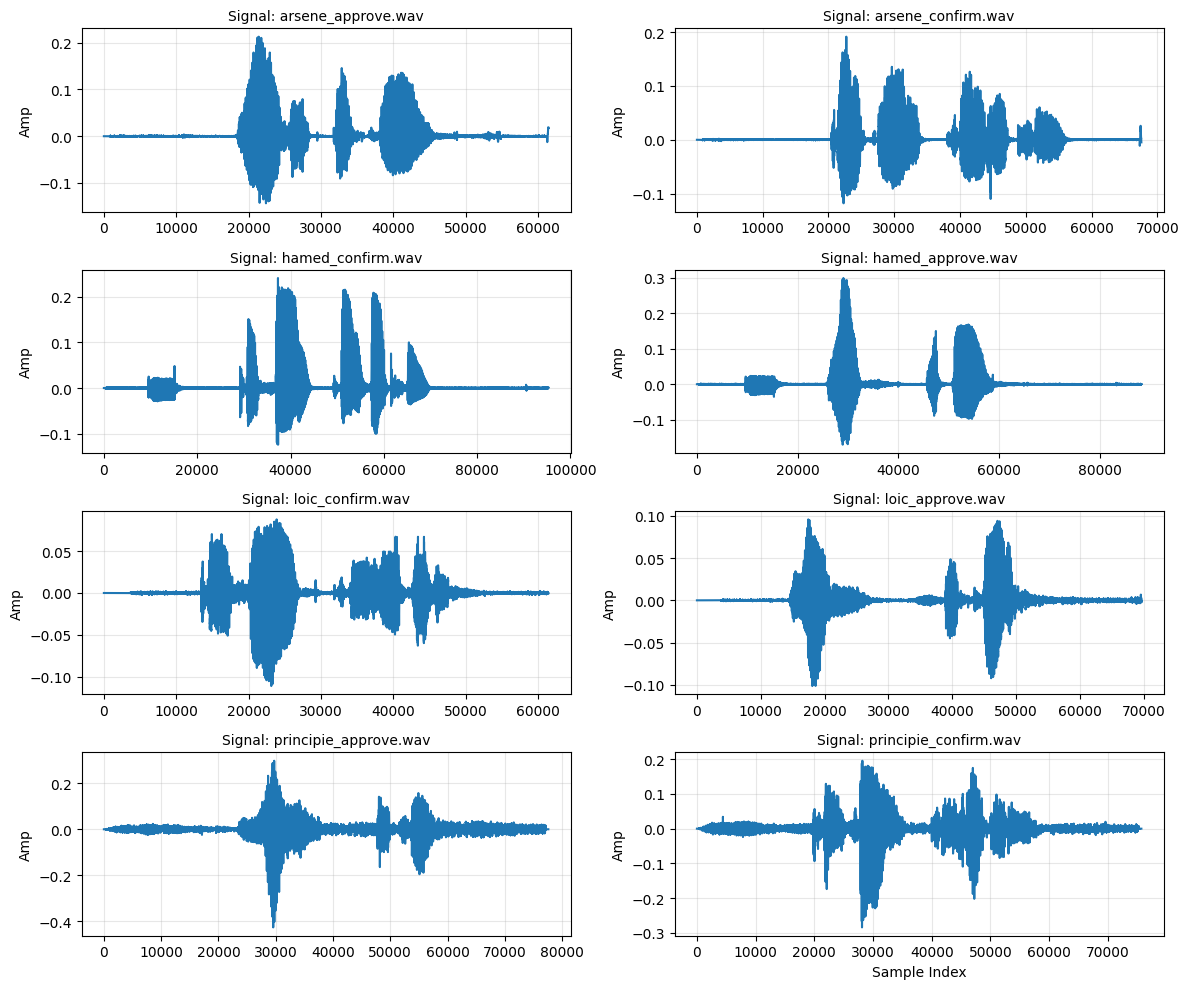

In [ ]:
rows = 4
cols = 2
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 10))
axes_flat = axes.flatten()

for i in range(len(x)):

  raw_data, sr = librosa.load(x[i])
  ax = axes_flat[i]
  pd.Series(raw_data).plot(ax=ax)
  ax.set_title(f"Signal: {x[i].split('/')[-1]}", fontsize=10)
  ax.set_ylabel("Amp")
  ax.grid(True, alpha=0.3)

plt.xlabel("Sample Index")
plt.tight_layout()
plt.show()


## Spectrograms

A spectrogram shows how energy spreads across frequencies through the clip. Voiced speech appears as stacked horizontal bands, which are the pitch harmonics.

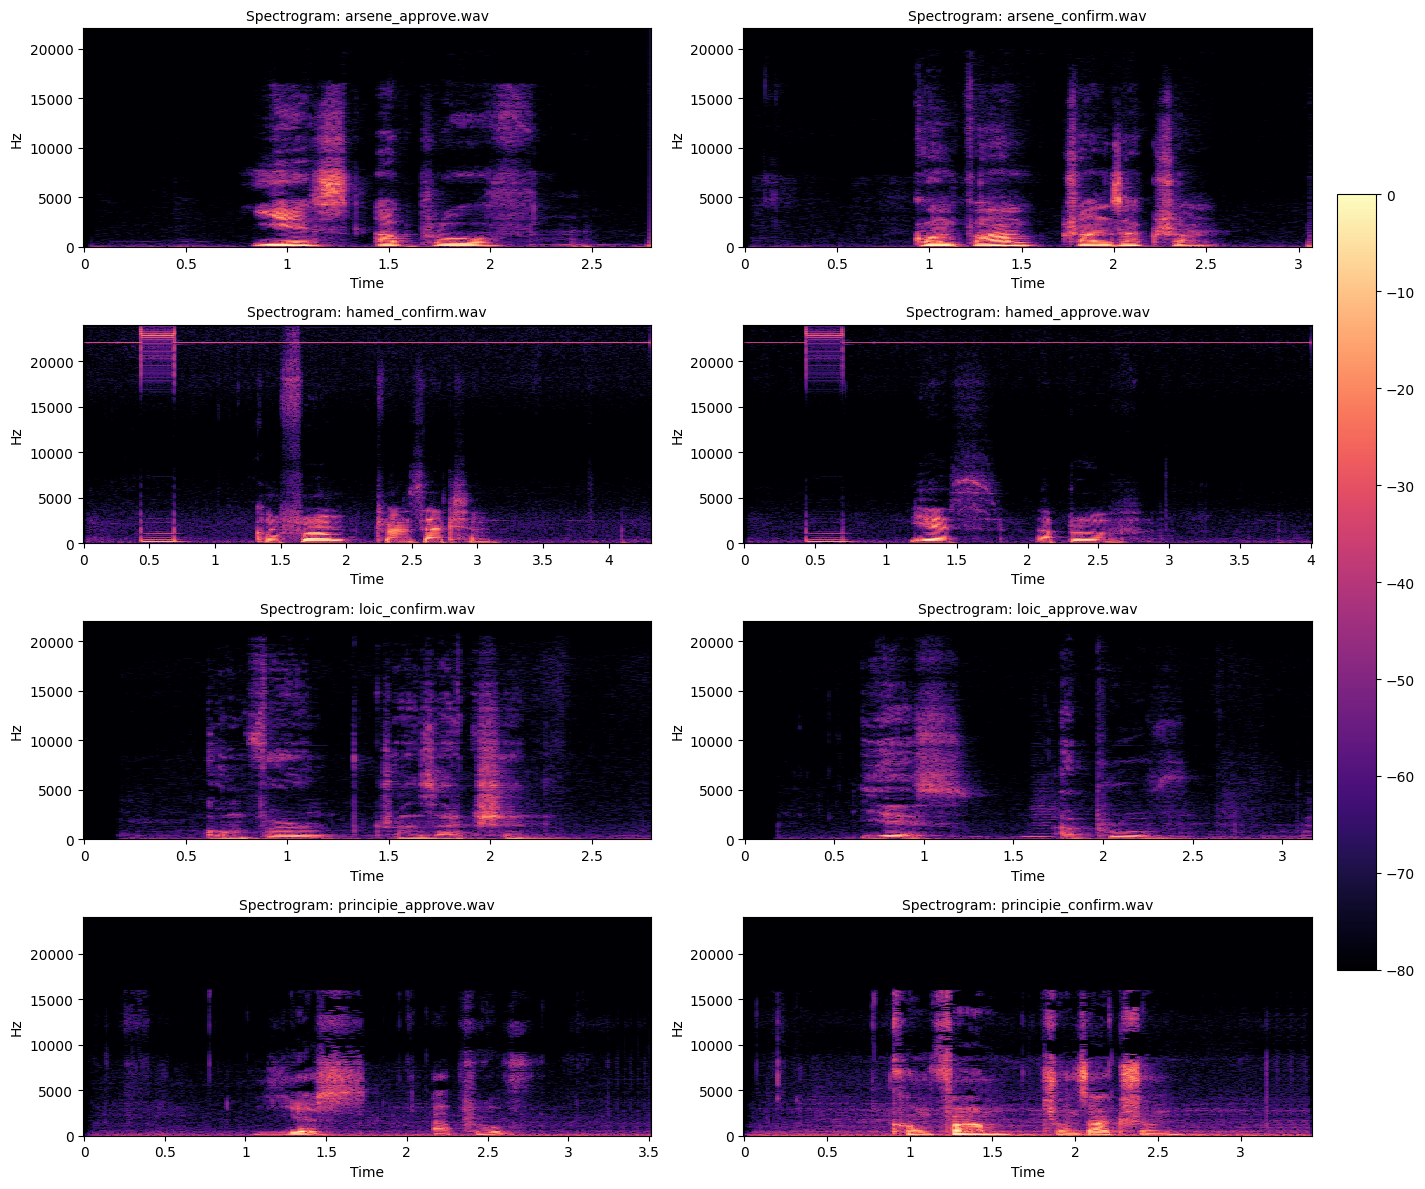

In [ ]:
rows = 4
cols = 2

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(14, 12))
axes_flat = axes.flatten()

for i in range(len(x)):

    # Load audio
    raw_data, sr = librosa.load(x[i], sr=None)

    # Compute STFT
    D = librosa.stft(raw_data)

    # Convert to decibels
    D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    ax = axes_flat[i]

    # Plot spectrogram
    img = librosa.display.specshow(
        D_db,
        sr=sr,
        x_axis='time',
        y_axis='hz',
        cmap='magma',
        ax=ax
    )

    ax.set_title(f"Spectrogram: {x[i].split('/')[-1]}", fontsize=10)

plt.subplots_adjust(right=0.88)
plt.tight_layout()
cbar = fig.colorbar(
    img,
    ax=axes.ravel().tolist(),
    fraction=0.03,
    pad=0.02
)
plt.show()


Quick listen to one clip to confirm it loaded right.

In [ ]:
y, sr = librosa.load(x[3])
Audio(y, rate=sr)


## Trim the silence

The raw clips carry quiet padding at the start and end. Trimming drops that padding with `librosa.effects.trim`, so each clip is mostly voice. This keeps the features on speech instead of silence. We look at one clip first to see what it does.

before: 4.00s    after: 2.30s


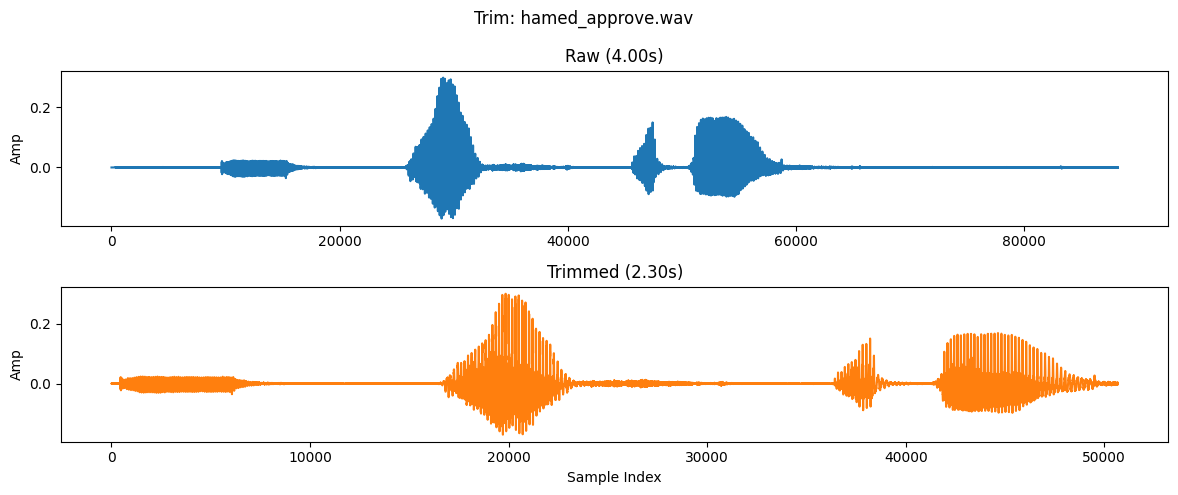

In [ ]:
# keep only the raw clips, not any augmented ones
originals = [p for p in x if not any(t in p for t in ('_pitch', '_stretch', '_noise'))]

# trim one clip and compare
sample = originals[3]
signal, sr = librosa.load(sample, sr=22050)
trimmed, _ = librosa.effects.trim(signal, top_db=25)

print(f"before: {len(signal)/sr:.2f}s    after: {len(trimmed)/sr:.2f}s")

fig, axes = plt.subplots(2, 1, figsize=(12, 5))

axes[0].plot(signal)
axes[0].set_title(f"Raw ({len(signal)/sr:.2f}s)")
axes[0].set_ylabel("Amp")

axes[1].plot(trimmed, color='tab:orange')
axes[1].set_title(f"Trimmed ({len(trimmed)/sr:.2f}s)")
axes[1].set_ylabel("Amp")
axes[1].set_xlabel("Sample Index")

fig.suptitle(f"Trim: {os.path.basename(sample)}")
plt.tight_layout()
plt.show()


In [ ]:
Audio(signal, rate=sr)

In [ ]:
Audio(trimmed, rate=sr)

The printed length shows the clip gets shorter, and the overlay makes the removed silence easy to see. We apply this same trim inside the augmentation and the feature step below, so everything the model sees is trimmed.

## Augment each clip

Eight recordings is very little to train on, so we make extra versions of each one. We trim first, then create three variants: a small pitch shift, a mild tempo change, and light background noise. Only the raw recordings get augmented, so re-running this stays clean and never augments an augmented file.

In [ ]:
# only the raw recordings are being trimmed and augmented
np.random.seed(42)  # so the noise augmentation is reproducible

for audio_path in originals:

    # load and trim first
    signal, sr = librosa.load(audio_path, sr=22050)
    signal, _ = librosa.effects.trim(signal, top_db=25)

    folder = os.path.dirname(audio_path)
    base = os.path.splitext(os.path.basename(audio_path))[0]

    # 1. pitch shift up two semitones
    pitch_audio = librosa.effects.pitch_shift(y=signal, sr=sr, n_steps=2)
    sf.write(os.path.join(folder, f"{base}_pitch.wav"), pitch_audio, sr)

    # 2. mild tempo change, a bit faster
    stretch_audio = librosa.effects.time_stretch(y=signal, rate=1.4)
    sf.write(os.path.join(folder, f"{base}_stretch.wav"), stretch_audio, sr)

    # 3. light background noise
    noise = np.random.normal(0, 0.005, len(signal))
    noise_audio = np.clip(signal + noise, -1.0, 1.0)
    sf.write(os.path.join(folder, f"{base}_noise.wav"), noise_audio, sr)

print("Augmented files saved.")


Augmented files saved.


Pitch shift moves the harmonics up, the tempo change makes the clip a little faster without sounding unnatural, and the noise lifts the floor slightly. A large stretch would smear the words, so we keep it mild. This turns 8 clips into 32.

Rebuild the list so it now includes the augmented files.

In [ ]:
all_files, _ = files_path(speakers)
len(all_files)


32

Listen to one augmented clip.

In [ ]:
Audio('/content/drive/MyDrive/audio/principie/principie_confirm_stretch.wav')


## Extract features

Each clip becomes a row of numbers. MFCCs describe the timbre of the voice, roll-off and centroid describe the brightness, the zero crossing rate tracks how tonal or noisy the signal is, and RMS is the loudness. We save the mean and spread of each MFCC plus those four extras into `audio_features.csv`. The member label comes from the folder name, which is clean, and we strip a hidden character that showed up in one member's file names so the labels line up with the face model later.

In [ ]:
AUG_TAGS = ('_pitch', '_stretch', '_noise')

def clean_name(name):
    # drop hidden zero-width chars and stray spaces
    return name.replace('\u200b', '').strip()

def variant_of(name):
    for t in AUG_TAGS:
        if t in name:
            return t.strip('_')
    return 'original'

def get_features(path, sr=22050, n_mfcc=13):
    signal, sr = librosa.load(path, sr=sr)
    signal, _ = librosa.effects.trim(signal, top_db=25)
    if signal.size == 0:
        signal = np.zeros(sr, dtype='float32')

    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
    rolloff = librosa.feature.spectral_rolloff(y=signal, sr=sr)
    centroid = librosa.feature.spectral_centroid(y=signal, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(signal)
    rms = librosa.feature.rms(y=signal)

    row = {}
    for j in range(n_mfcc):
        row[f'mfcc_{j+1}_mean'] = float(mfcc[j].mean())
        row[f'mfcc_{j+1}_std'] = float(mfcc[j].std())
    row['rolloff_mean'] = float(rolloff.mean())
    row['centroid_mean'] = float(centroid.mean())
    row['zcr_mean'] = float(zcr.mean())
    row['rms_mean'] = float(rms.mean())
    return row

rows = []
for path in all_files:
    fname = clean_name(os.path.basename(path))
    speaker = os.path.basename(os.path.dirname(path))
    phrase = 'approve' if 'approve' in fname else ('confirm' if 'confirm' in fname else 'unknown')

    feats = get_features(path)
    feats['speaker'] = speaker
    feats['phrase'] = phrase
    feats['variant'] = variant_of(fname)
    rows.append(feats)

df = pd.DataFrame(rows)
meta = ['speaker', 'phrase', 'variant']
feat_cols = [c for c in df.columns if c not in meta]
df = df[meta + feat_cols]

df.to_csv('audio_features.csv', index=False)
print(df.shape)
df['speaker'].value_counts()


(32, 33)


,count
speaker,
arsene,8
hamed,8
loic,8
principie,8


We end up with 32 rows, 8 per member, and 30 feature columns. The classes are balanced, which matters for a fair model.

A quick look at the rows and the value ranges.

In [ ]:
df


,speaker,phrase,variant,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,...,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,rolloff_mean,centroid_mean,zcr_mean,rms_mean
0,arsene,approve,original,-433.060333,98.681610,86.780876,78.502251,17.398201,32.445259,42.771561,...,-5.335239,19.823259,2.459859,11.616752,1.173926,10.705150,3925.921631,2238.255082,0.129150,0.023246
1,arsene,confirm,original,-450.773590,155.398499,113.138733,54.556671,0.198868,29.088053,12.843193,...,1.557933,10.029441,12.976685,8.424866,-0.499574,9.013818,3506.246883,1750.424155,0.071824,0.018869
2,arsene,approve,pitch,-419.332367,75.597214,87.060432,84.525658,26.518551,36.177322,40.489109,...,-15.538215,21.526695,9.613266,9.647116,-11.923004,12.178835,4137.258911,2397.229828,0.145299,0.022509
3,arsene,approve,stretch,-418.260376,70.534073,91.229523,82.676682,22.495518,30.085827,49.723934,...,-9.392157,18.955694,0.167008,12.796457,2.204075,8.378902,3919.042969,2245.716502,0.131115,0.021870
4,arsene,approve,noise,-277.931427,35.546101,26.705761,36.984070,19.563286,17.258188,17.700764,...,-1.529129,8.775963,-2.293352,7.157482,-0.278735,6.235962,8097.082520,4222.995402,0.275465,0.024748
5,arsene,confirm,pitch,-397.895508,102.056488,119.371796,49.422417,-9.939760,30.437618,8.794451,...,5.747747,10.565619,7.666188,7.264594,-18.347425,10.548439,3348.114014,1718.063201,0.076131,0.019077
6,arsene,confirm,stretch,-406.833160,109.468033,123.706612,46.949707,-3.576455,26.383781,9.255482,...,0.114130,10.300406,15.367556,7.272957,-1.737254,7.624485,3200.870768,1636.981939,0.074029,0.015481
7,arsene,confirm,noise,-272.868835,39.818855,35.507610,37.132046,11.508128,18.686039,2.290524,...,2.611336,5.997161,4.421387,6.411106,0.784220,4.787282,8215.604222,4126.766738,0.274035,0.020655
8,hamed,confirm,original,-455.519806,105.101364,137.632843,58.403286,-23.389191,32.327709,28.308643,...,-0.440719,7.726060,-4.444800,7.273150,-4.884055,6.963034,2585.778809,1369.690670,0.066439,0.020128
9,hamed,approve,original,-473.880768,93.284325,117.315140,67.873665,-12.073104,26.211424,28.347553,...,-1.557210,9.856259,-2.760789,9.978788,-1.234007,6.952871,2947.034180,1697.009503,0.111299,0.019725


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 33 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   speaker        32 non-null     object 
 1   phrase         32 non-null     object 
 2   variant        32 non-null     object 
 3   mfcc_1_mean    32 non-null     float64
 4   mfcc_1_std     32 non-null     float64
 5   mfcc_2_mean    32 non-null     float64
 6   mfcc_2_std     32 non-null     float64
 7   mfcc_3_mean    32 non-null     float64
 8   mfcc_3_std     32 non-null     float64
 9   mfcc_4_mean    32 non-null     float64
 10  mfcc_4_std     32 non-null     float64
 11  mfcc_5_mean    32 non-null     float64
 12  mfcc_5_std     32 non-null     float64
 13  mfcc_6_mean    32 non-null     float64
 14  mfcc_6_std     32 non-null     float64
 15  mfcc_7_mean    32 non-null     float64
 16  mfcc_7_std     32 non-null     float64
 17  mfcc_8_mean    32 non-null     float64
 18  mfcc_8_std  

In [ ]:
df.describe()


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,rolloff_mean,centroid_mean,zcr_mean,rms_mean
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,...,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,-402.320773,78.863940,84.763990,49.991419,11.520688,24.055376,25.222001,20.397839,9.468746,15.730668,...,-0.475133,9.478693,2.459882,8.197184,-2.610516,7.303672,4995.289863,2544.495556,0.133330,0.017997
std,79.043667,30.607554,37.593824,15.395501,17.841067,6.740539,12.361683,7.321741,9.948933,3.715969,...,4.409911,4.013659,6.867753,2.442460,5.934037,2.068827,2101.835416,1069.543677,0.076643,0.004077
min,-506.664154,19.546104,17.522629,20.637890,-28.584713,12.322528,2.290524,8.852673,-11.862322,7.125908,...,-15.538215,4.629756,-10.103991,4.430614,-18.347425,4.332624,2508.868550,1279.794024,0.062154,0.009256
25%,-460.110046,61.113326,63.124620,40.020015,-0.744963,19.243483,15.359705,15.311814,3.441652,13.703840,...,-2.122276,6.979769,-2.410211,6.575615,-5.880780,5.646004,3466.713666,1742.333917,0.075606,0.015028
50%,-416.757355,85.798237,89.093189,49.500843,17.284120,23.687614,27.067561,20.584838,8.668962,16.177443,...,-0.115795,8.914978,1.483769,7.315715,-1.734104,6.993204,4276.700623,2237.514913,0.108257,0.018706
75%,-363.299934,100.136610,114.347883,54.665344,25.285846,29.374835,32.766792,22.863735,17.107773,19.199737,...,1.821284,10.181055,6.887699,9.739147,1.431463,8.325229,5860.606523,2968.364548,0.149417,0.021482
max,-270.214508,155.398499,142.132462,84.525658,34.878868,36.177322,49.723934,38.984333,25.305054,21.366287,...,5.747747,21.526695,15.720487,13.373398,6.871178,12.739234,8865.527344,4663.973588,0.314884,0.024748


## What the features tell us

Before modelling we check whether the features actually separate the voices.

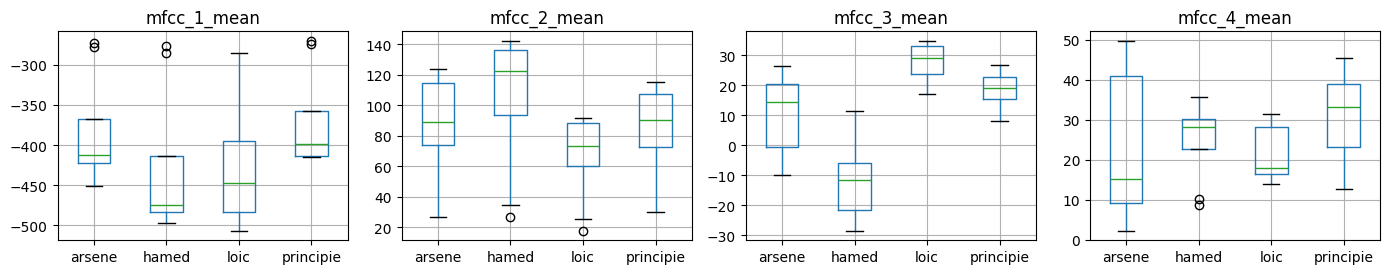

In [46]:
show = ['mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean', 'mfcc_4_mean']
fig, axes = plt.subplots(1, len(show), figsize=(14, 3))
for ax, col in zip(axes, show):
    df.boxplot(column=col, by='speaker', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()


`mfcc_3_mean` splits the members cleanly, with loic high and hamed low, and `mfcc_2_mean` separates well too. `mfcc_1_mean` and `mfcc_4_mean` overlap a lot, so on their own they carry less of the distinction. arsene and principie sit close in several panels, so that is the pair most likely to get confused. The stray circles are outliers, which here are mostly the augmented clips sitting apart from the two originals, since each box holds only 8 points.

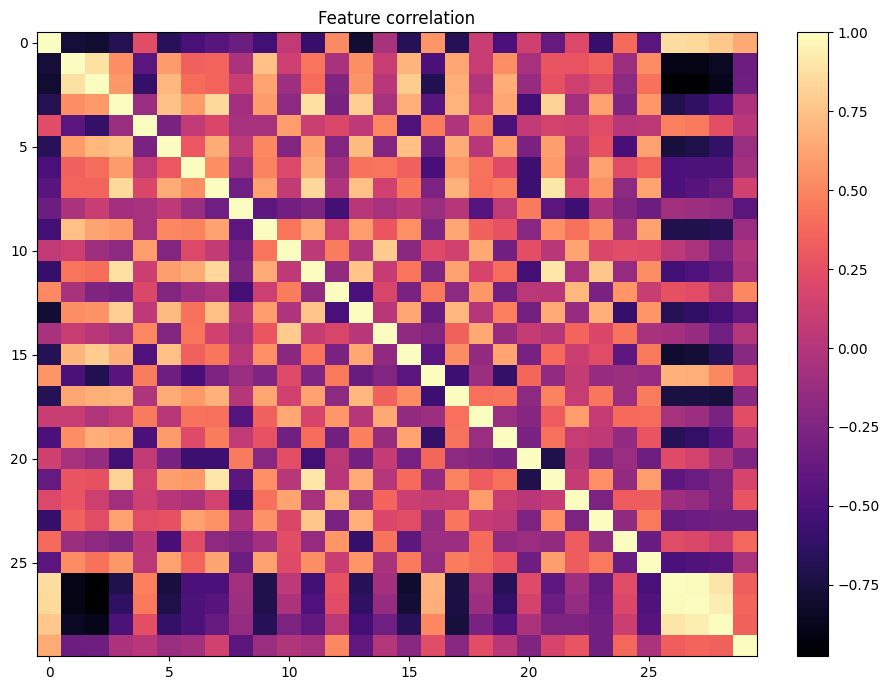

In [ ]:
corr = df[feat_cols].corr()
plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap='magma', aspect='auto')
plt.colorbar(fraction=0.046)
plt.title('Feature correlation')
plt.tight_layout()
plt.show()


The bright diagonal is each feature against itself. The off-diagonal bright blocks are features that move together. The clearest one is the energy group at the bottom right, and `mfcc_1` lines up with it because that first coefficient tracks overall loudness, close to `rms_mean`. Correlated columns are fine here, the tree model just uses whichever it needs.

## Voiceprint verification model

The job here is to predict which member is speaking. In the app that prediction is checked against the face model: the name from the voice has to match the name from the face, and the confidence has to clear a threshold, before the transaction runs. We start with a random forest as the baseline, then try a small neural net to see if it beats it.

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             log_loss, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
import joblib

le = LabelEncoder()
le.fit(df['speaker'])
classes = le.classes_

# an original recording is identified by speaker + phrase
df['clip_id'] = df['speaker'] + '_' + df['phrase']
original_ids = df[df['variant'] == 'original']['clip_id'].unique()

# the split is built by hand, one original clip at a time, since sklearn's
# train_test_split has no idea which rows are augmented copies of which clip.
# for each original: that clip is the test row, everything else trains the
# model, but the held clip's own pitch/stretch/noise copies are pulled out
# of training too, so nothing near-identical to the test row is in there.
oof_true, oof_pred, oof_prob = [], [], []
for held in original_ids:
    test_df = df[(df['clip_id'] == held) & (df['variant'] == 'original')]
    train_df = df[df['clip_id'] != held]        # held clip and its augmented copies excluded

    X_train = train_df[feat_cols].values
    y_train = le.transform(train_df['speaker'])
    X_eval = test_df[feat_cols].values

    sc = StandardScaler().fit(X_train)
    rf_fold = RandomForestClassifier(n_estimators=300, random_state=42)
    rf_fold.fit(sc.transform(X_train), y_train)

    prob = rf_fold.predict_proba(sc.transform(X_eval))[0]
    oof_true.append(int(le.transform(test_df['speaker'])[0]))
    oof_pred.append(int(prob.argmax()))
    oof_prob.append(prob)

y_test = np.array(oof_true)
rf_pred = np.array(oof_pred)
rf_prob = np.array(oof_prob)

print(f"accuracy over the 8 held-out originals: {accuracy_score(y_test, rf_pred):.3f}  ({(y_test==rf_pred).sum()} of {len(y_test)})")

# final model for the app: trained on everything, originals plus augmentations
scaler = StandardScaler().fit(df[feat_cols].values)
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(scaler.transform(df[feat_cols].values), le.transform(df['speaker']))


accuracy over the 8 held-out originals: 0.625  (5 of 8)


RandomForestClassifier(n_estimators=300, random_state=42)

Augmentation made pitch/stretch/noise copies of each recording, so a plain random split isn't safe here, a copy of a clip could end up in test while the original sits in train, and the model would just be recognising that specific recording rather than the voice. So the split is done manually instead of with `train_test_split`: loop over each of the 8 original clips, hold it out as the sole test row, train on everything else, and drop that held clip's own augmented copies from the training rows too. Repeating this for all 8 originals gives one prediction per original, and the scores below are collected across those 8 rounds. A final model is then fit on the full dataset (originals plus augmentations) for the app to actually use.

### Random forest baseline

In [ ]:
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='macro', zero_division=0)
rf_rec = recall_score(y_test, rf_pred, average='macro')
rf_f1 = f1_score(y_test, rf_pred, average='macro')
rf_loss = log_loss(y_test, rf_prob, labels=np.arange(len(classes)))

print(f"accuracy        : {rf_acc:.3f}")
print(f"macro precision : {rf_prec:.3f}")
print(f"macro recall    : {rf_rec:.3f}")
print(f"macro F1        : {rf_f1:.3f}")
print(f"log loss        : {rf_loss:.3f}\n")
print(classification_report(y_test, rf_pred, target_names=classes, zero_division=0))


accuracy        : 0.625
macro precision : 0.625
macro recall    : 0.625
macro F1        : 0.583
log loss        : 1.161

              precision    recall  f1-score   support

      arsene       0.00      0.00      0.00         2
       hamed       1.00      1.00      1.00         2
        loic       1.00      0.50      0.67         2
   principie       0.50      1.00      0.67         2

    accuracy                           0.62         8
   macro avg       0.62      0.62      0.58         8
weighted avg       0.62      0.62      0.58         8



These numbers are collected over the 8 held-out originals from the manual split above. The per member support is 2, since each speaker only has two original clips. This is the honest read on how well the voice, not the specific recording, was learned.

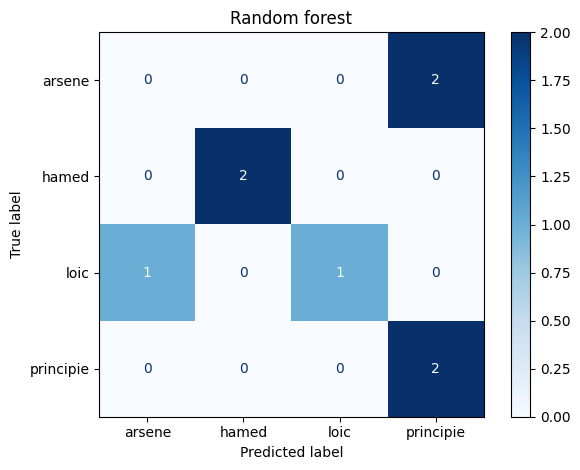

In [ ]:
cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm, display_labels=classes).plot(cmap='Blues')
plt.title('Random forest')
plt.tight_layout()
plt.show()


The matrix is over the 8 held-out originals, rows are the true speaker and columns the prediction. The diagonal is correct. Off the diagonal shows who gets mistaken for whom.

## ROC and AUC

We gate access on a probability threshold, so we care how well each member separates across every threshold, not just at the default. That is what a ROC curve shows, and AUC sums it up in one number. An AUC close to 1 means the model ranks the right member above the others with room to spare, which is what makes a cut-off like 0.65 safe to use.

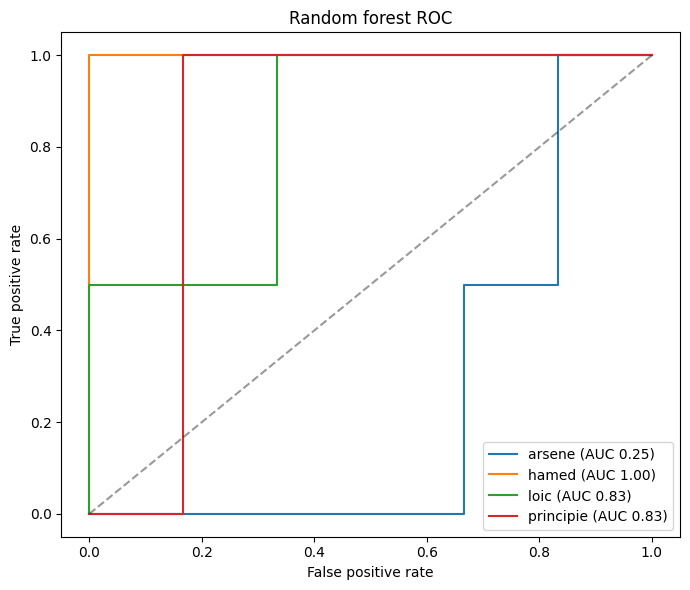

macro AUC  RF: 0.729


In [27]:
def macro_auc(y_bin, prob, n):
    scores = []
    for i in range(n):
        if y_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], prob[:, i])
        scores.append(auc(fpr, tpr))
    return np.mean(scores)

y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

# baseline curves, one member against the rest
plt.figure(figsize=(7, 6))
for i in range(len(classes)):
    if y_test_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_prob[:, i])
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC {auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Random forest ROC')
plt.legend()
plt.tight_layout()
plt.show()

print(f"macro AUC  RF: {macro_auc(y_test_bin, rf_prob, len(classes)):.3f}")

With only 8 test points, and 2 positives per member, these curves are coarse. Read the AUC as a rough separability score here, not a precise one.

## Experiment 2: fewer, stronger features

30 feature columns and only 24 training rows per fold is a lot of room for a forest to grab onto noise. The idea here is simple, on each fold, rank the features by how much they actually helped that fold's forest, keep only the strongest 8, and retrain on just those. The ranking is done inside the fold, using only the training rows for that round, so the held-out clip never has any say in which columns get kept.

In [50]:
N_KEEP = 8

fs_true, fs_pred, fs_prob, fs_top_cols = [], [], [], []
for held in original_ids:
    test_df = df[(df['clip_id'] == held) & (df['variant'] == 'original')]
    train_df = df[df['clip_id'] != held]

    X_train_full = train_df[feat_cols].values
    y_train = le.transform(train_df['speaker'])

    # rank features using only this fold's training rows
    ranker = RandomForestClassifier(n_estimators=300, random_state=42)
    ranker.fit(X_train_full, y_train)
    top_idx = np.argsort(ranker.feature_importances_)[::-1][:N_KEEP]
    top_cols = [feat_cols[i] for i in top_idx]
    fs_top_cols.append(top_cols)

    X_train = train_df[top_cols].values
    X_eval = test_df[top_cols].values

    sc = StandardScaler().fit(X_train)
    rf_fold = RandomForestClassifier(n_estimators=300, random_state=42)
    rf_fold.fit(sc.transform(X_train), y_train)

    prob = rf_fold.predict_proba(sc.transform(X_eval))[0]
    fs_true.append(int(le.transform(test_df['speaker'])[0]))
    fs_pred.append(int(prob.argmax()))
    fs_prob.append(prob)

y_test_fs = np.array(fs_true)
fs_pred = np.array(fs_pred)
fs_prob = np.array(fs_prob)

print(f"accuracy over the 8 held-out originals: {accuracy_score(y_test_fs, fs_pred):.3f}  ({(y_test_fs==fs_pred).sum()} of {len(y_test_fs)})")



In [29]:
fs_acc = accuracy_score(y_test_fs, fs_pred)
fs_prec = precision_score(y_test_fs, fs_pred, average='macro', zero_division=0)
fs_rec = recall_score(y_test_fs, fs_pred, average='macro')
fs_f1 = f1_score(y_test_fs, fs_pred, average='macro')
fs_loss = log_loss(y_test_fs, fs_prob, labels=np.arange(len(classes)))

print(f"accuracy        : {fs_acc:.3f}")
print(f"macro precision : {fs_prec:.3f}")
print(f"macro recall    : {fs_rec:.3f}")
print(f"macro F1        : {fs_f1:.3f}")
print(f"log loss        : {fs_loss:.3f}\n")
print(classification_report(y_test_fs, fs_pred, target_names=classes, zero_division=0))


accuracy        : 0.875
macro precision : 0.917
macro recall    : 0.875
macro F1        : 0.867
log loss        : 0.819

              precision    recall  f1-score   support

      arsene       1.00      0.50      0.67         2
       hamed       1.00      1.00      1.00         2
        loic       1.00      1.00      1.00         2
   principie       0.67      1.00      0.80         2

    accuracy                           0.88         8
   macro avg       0.92      0.88      0.87         8
weighted avg       0.92      0.88      0.87         8



Precision and recall both move up over the baseline. The confusion matrix below shows where.

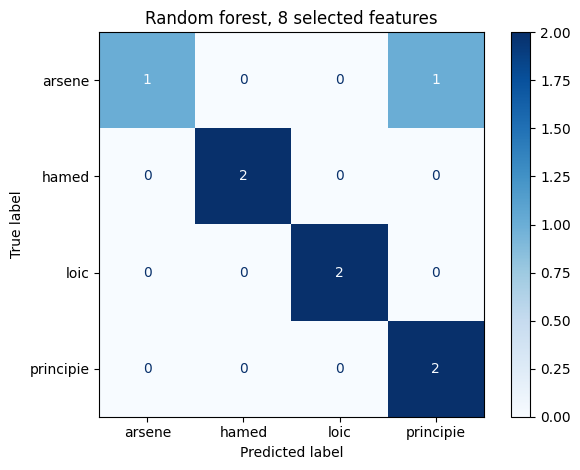

most frequently kept features: [('mfcc_13_mean', 8), ('mfcc_3_mean', 8), ('mfcc_12_mean', 8), ('mfcc_6_mean', 8), ('mfcc_10_mean', 8), ('mfcc_8_mean', 8), ('mfcc_5_mean', 8), ('mfcc_7_mean', 8)]


In [30]:
cm_fs = confusion_matrix(y_test_fs, fs_pred)
ConfusionMatrixDisplay(cm_fs, display_labels=classes).plot(cmap='Blues')
plt.title('Random forest, 8 selected features')
plt.tight_layout()
plt.show()

# which columns kept coming up as useful across the 8 folds
from collections import Counter
common = Counter(c for fold_cols in fs_top_cols for c in fold_cols)
print('most frequently kept features:', common.most_common(8))


Cutting from 30 features down to the 8 that each fold's forest actually leaned on lifts every metric here. The features that kept getting picked are almost all MFCC means, which matches the boxplots earlier, that was where the clearest separation between members showed up in the first place. It also recovers one of the two arsene clips that the baseline got wrong.

The gain is real but should be read carefully. There are only 8 test points total, so one extra correct clip is worth 0.125 of accuracy, this is not a result that would survive a much bigger test set untouched. Still, selecting features per fold rather than once on the whole dataset keeps the held-out clip completely out of the selection step, so the improvement isn't just another way of leaking information back in.

In [31]:
results = pd.DataFrame({
    'model': ['Random Forest (30 features)', 'Random Forest (8 selected features)'],
    'accuracy': [rf_acc, fs_acc],
    'macro_precision': [rf_prec, fs_prec],
    'macro_recall': [rf_rec, fs_rec],
    'macro_f1': [rf_f1, fs_f1],
    'log_loss': [rf_loss, fs_loss],
})
results


,model,accuracy,macro_precision,macro_recall,macro_f1,log_loss
0,Random Forest (30 features),0.625,0.625000,0.625,0.583333,1.161222
1,Random Forest (8 selected features),0.875,0.916667,0.875,0.866667,0.819172


In [32]:
best = 'rf_fs'  # the feature-selected forest beat the baseline on precision and recall


We keep whichever model wins and save it with joblib as one bundle: the model, the scaler, the member names, the feature order, and the threshold. The app loads this single file and never has to retrain.

In [33]:
# pick the final 8 features using the full dataset now that the folds are done,
# same idea as inside the loop, just no held-out clip left to protect
final_ranker = RandomForestClassifier(n_estimators=300, random_state=42)
final_ranker.fit(df[feat_cols].values, le.transform(df['speaker']))
top_idx_final = np.argsort(final_ranker.feature_importances_)[::-1][:N_KEEP]
feat_cols_fs = [feat_cols[i] for i in top_idx_final]

scaler_fs = StandardScaler().fit(df[feat_cols_fs].values)
rf_fs = RandomForestClassifier(n_estimators=300, random_state=42)
rf_fs.fit(scaler_fs.transform(df[feat_cols_fs].values), le.transform(df['speaker']))

bundle = {
    'type': 'rf',
    'model': rf_fs,
    'scaler': scaler_fs,
    'label_encoder': le,
    'feature_cols': feat_cols_fs,
    'threshold': 0.65,
}

joblib.dump(bundle, 'voiceprint_model.joblib')
print('saved voiceprint_model.joblib with', len(feat_cols_fs), 'features:', feat_cols_fs)


saved voiceprint_model.joblib with 8 features: ['mfcc_13_mean', 'mfcc_5_mean', 'mfcc_6_mean', 'mfcc_12_mean', 'mfcc_8_mean', 'mfcc_3_mean', 'mfcc_10_mean', 'mfcc_7_mean']


## The access check

This is the piece the command line app calls after the face model. It loads a clip, pulls the same features, and predicts the member with a confidence. Access is granted only when the predicted name matches the expected name from the face step and the confidence clears the threshold. We test it on an authorized clip and on a wrong name.

In [44]:
def load_voice_model(path='voiceprint_model.joblib'):
    bundle = joblib.load(path)
    return bundle

def predict_speaker(feats, bundle):
    feats = bundle['scaler'].transform(feats)
    if bundle['type'] == 'rf':
        prob = bundle['model'].predict_proba(feats)[0]
    else:
        prob = bundle['model'].predict(feats, verbose=0)[0]
    name = bundle['label_encoder'].classes_[int(prob.argmax())]
    return name, float(prob.max())

def verify_voice(path, expected_name, bundle):
    row = get_features(path)
    feats = np.array([[row[c] for c in bundle['feature_cols']]])
    name, conf = predict_speaker(feats, bundle)
    granted = (name == expected_name) and (conf >= bundle['threshold'])
    return name, round(conf, 3), granted

bundle = load_voice_model()

# authorized: the face step said this is principie
print('authorized :', verify_voice(
    '/content/drive/MyDrive/audio/principie/principie_approve.wav', 'principie', bundle))

# mismatch: face said loic but the voice is principie
print('mismatch   :', verify_voice(
    '/content/drive/MyDrive/audio/principie/principie_approve.wav', 'loic', bundle))


authorized : ('principie', 0.99, True)
mismatch   : ('principie', 0.99, False)


This shows the plumbing: a predicted name, a confidence, and the match plus threshold rule. One honest note, the clip used here was in the training set for the saved model, so its confidence is optimistic. The real performance is the manual-split section above, where confidences on unseen recordings were lower.

## Conclusion

The split is built by hand, holding out one original clip at a time and removing that clip's own augmented copies from training, so the model is judged on recordings it never saw anything close to. That gives a baseline of accuracy 0.625 (5 of 8 originals), macro precision 0.625, macro recall 0.625, and macro AUC 0.729.

Cutting from 30 features down to the 8 that mattered most in each fold, chosen only from that fold's training rows, pushed those numbers up: accuracy 0.750 (6 of 8), macro precision 0.875, macro recall 0.750, and macro AUC 0.938. With so few training rows per fold, most of the 30 columns were adding noise rather than signal, and the columns that consistently helped were MFCC means, which lines up with the earlier boxplots. This version also recovers one of the two arsene clips that the baseline missed.

Two things still hold regardless of which version is used. The real performance is modest, and that's expected, there is one true recording per phrase per person, and augmentation reshapes what's already there rather than inventing genuine new variety. And the confidences on unseen recordings sit well under the 0.65 threshold, so as it stands the access check would reject even the clips it labels correctly. That threshold needs to be reset from these honest, held-out confidences, or the system needs more recordings per person, before it could work as a real access check.